In [1]:
import matplotlib as mpl
mpl.rcParams.update(mpl.rcParamsDefault)
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import json


### New output format for L shaped results

In [9]:
with open("DE_results_T_10_delta_5_scen_4_trial_1_inv_1_cap._1_cap.inc._2_base.json") as json_file:
    data = json.load(json_file)

start_DF = pd.read_excel("../../DATA/Starting_point.xlsx", sheet_name="F_start")
start_DF["Value"] = 1
start_DF.rename(columns={"Antigen": "Tender", "Starting": "Start", "Ending": "Finish"}, inplace=True)

Overlapping periods found:
Overlap in antigen PCV from 2 to 3
Overlap in antigen PCV from 5 to 6
Overlap in antigen Measles from 5 to 6
Overlap in antigen Mumps from 5 to 6
Overlap in antigen Hib from 5 to 6
Overlap in antigen Pertussis from 5 to 6
Overlap in antigen Rotavirus from 5 to 6
Overlap in antigen Polio from 5 to 6
Overlap in antigen Diphtheria from 5 to 6
Overlap in antigen Hepatitis_B from 5 to 6
Overlap in antigen Tetanus from 5 to 6
Overlap in antigen Rubella from 5 to 6


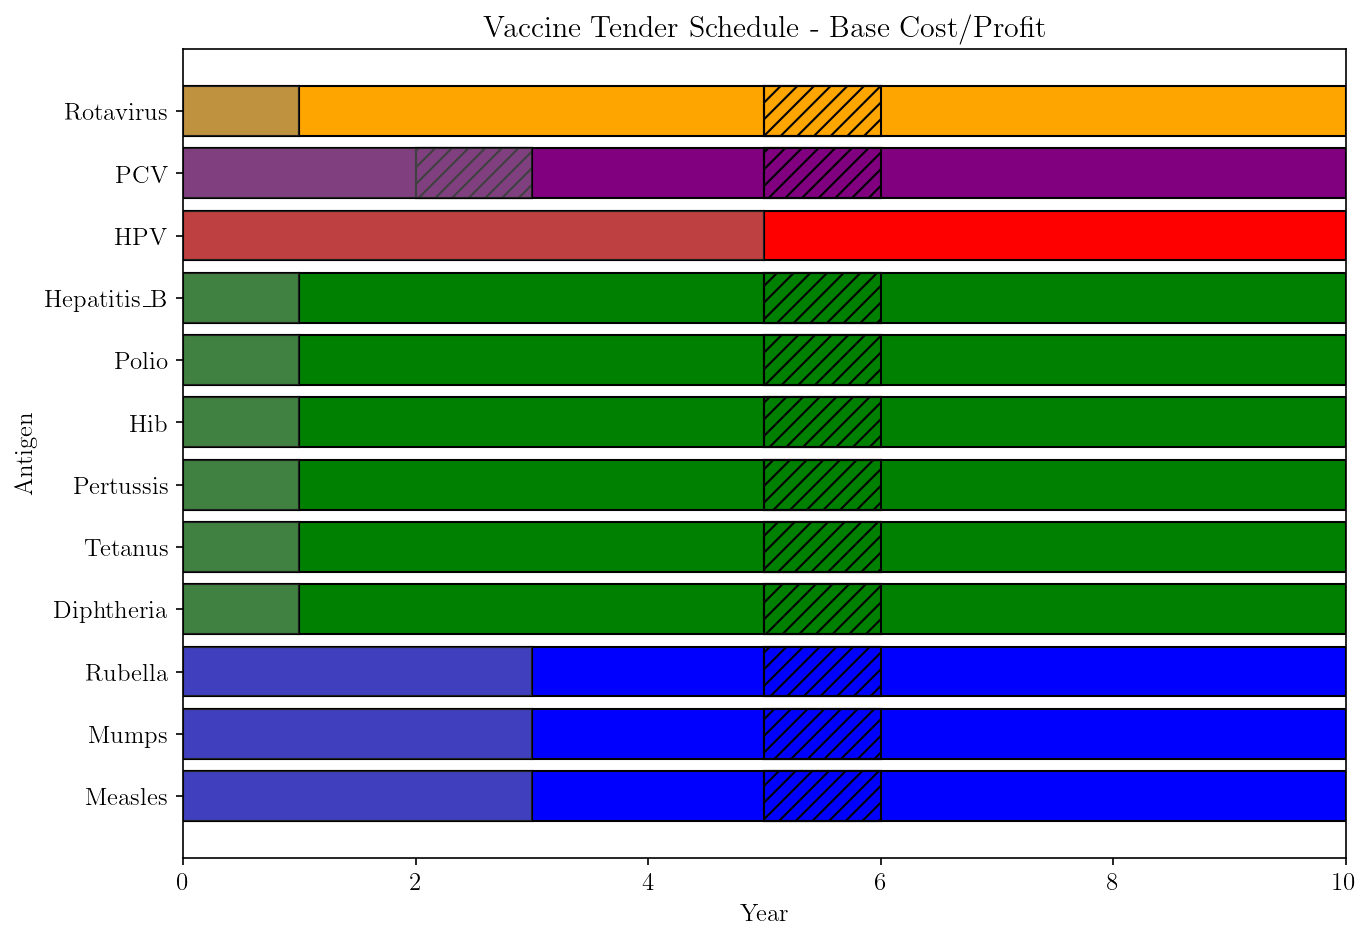

In [10]:
# Update plot settings
plt.rcParams.update(
    {
        "font.family": "serif",
        "font.serif": "CMU Serif",
        "text.usetex": True,
        "text.latex.preamble": r"\usepackage{amsmath}",
        "font.size": 12,
        "font.weight": "normal",
        "figure.titlesize": "medium",
        "xtick.color": "black",
        "ytick.color": "black",
        "axes.labelcolor": "black",
        "text.color": "black",
        "savefig.dpi": 300,
        "figure.dpi": 150,
        "savefig.bbox": "tight",
    }
)

# Extract values for the key 'F'
f_values = data.get('F', {})

# Prepare data for checking overlaps
periods = {antigen: [] for antigen in f_values.keys()}

for antigen, periods_dict in f_values.items():
    for start, ends_dict in periods_dict.items():
        for end, value in ends_dict.items():
            if value == 1.0:
                adjusted_start = int(start) - 1
                periods[antigen].append((adjusted_start, int(end)))

# Check for overlaps within each antigen
overlaps = {antigen: [] for antigen in f_values.keys()}

for antigen, period_list in periods.items():
    period_list.sort()  # Sort periods by start time
    for i in range(1, len(period_list)):
        prev_start, prev_end = period_list[i-1]
        curr_start, curr_end = period_list[i]
        if curr_start < prev_end:  # Overlap condition
            overlap_start = curr_start
            overlap_end = min(prev_end, curr_end)
            overlaps[antigen].append((overlap_start, overlap_end))

# Output results
if any(overlaps.values()):
    print("Overlapping periods found:")
    for antigen, overlap_list in overlaps.items():
        for overlap in overlap_list:
            print(f"Overlap in antigen {antigen} from {overlap[0]} to {overlap[1]}")
else:
    print("No overlapping periods found.")

# Define colors for each group
colors = {
    "MMR Antigens": "blue",
    "Hexa Antigens": "green",
    "HPV": "red",
    "PCV": "purple",
    "Rota": "orange",
}

color_groups = {
    "MMR Antigens": ["Measles", "Mumps", "Rubella"],
    "Hexa Antigens": ["Diphtheria", "Tetanus", "Pertussis", "Hib", "Polio", "Hepatitis_B"],
    "HPV": ["HPV"],
    "PCV": ["PCV"],
    "Rota": ["Rotavirus"],
}

tender_order = [
    "Measles",
    "Mumps",
    "Rubella",
    "Diphtheria",
    "Tetanus",
    "Pertussis",
    "Hib",
    "Polio",
    "Hepatitis_B",
    "HPV",
    "PCV",
    "Rotavirus",
]

antigen_colors = {}
for group, antigens in color_groups.items():
    for antigen in antigens:
        antigen_colors[antigen] = colors[group]

# Plotting all periods
fig, ax = plt.subplots(figsize=(10, 7))

hatch = '///'

for i, antigen in enumerate(tender_order):
    color = antigen_colors.get(antigen, 'gray')
    antigen_periods = periods.get(antigen, [])
    for start, end in antigen_periods:
        ax.barh(i, end-start, left=start, color=color, edgecolor='black', align='center')
    
    antigen_overlaps = overlaps.get(antigen, [])
    for overlap_start, overlap_end in antigen_overlaps:
        ax.barh(i, overlap_end-overlap_start, left=overlap_start, color='none', edgecolor='black', align='center', hatch=hatch)

# Plotting the starting points as 50% translucent grey bars
for idx, row in start_DF.iterrows():
    antigen = row['Tender']
    if antigen in tender_order:
        i = tender_order.index(antigen)
        adjusted_start = row['Start'] - 1
        ax.barh(i, row['Finish'] - adjusted_start, left=adjusted_start, color='grey', alpha=0.5, edgecolor='black', align='center')

# Set the labels and titles
ax.set_yticks(range(len(tender_order)))
ax.set_yticklabels(tender_order)
ax.set_xlabel('Year')
ax.set_ylabel('Antigen')
ax.set_title('Vaccine Tender Schedule - Base Cost/Profit')

# Add gridlines and set limits for x-axis
ax.set_xlim(0, 10)

plt.savefig('Tender_schedule_base.png', bbox_inches='tight', pad_inches=0.1, dpi=600)

plt.show()
